In [3]:
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import ConfusionMatrixDisplay
import os
from datetime import datetime
from openpyxl import load_workbook, Workbook
import pandas as pd
import random
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from keras.models import Sequential
from keras.layers import Dense
import numpy as np

## red wine quality

In [4]:
red = pd.read_csv("redwinequality.csv", sep=';')
white = pd.read_csv("whitewinequality.csv", sep=';')

red['type'] = 1
white['type'] = 0

wines = pd.concat([red, white], ignore_index=True)
wines.dropna(inplace=True)

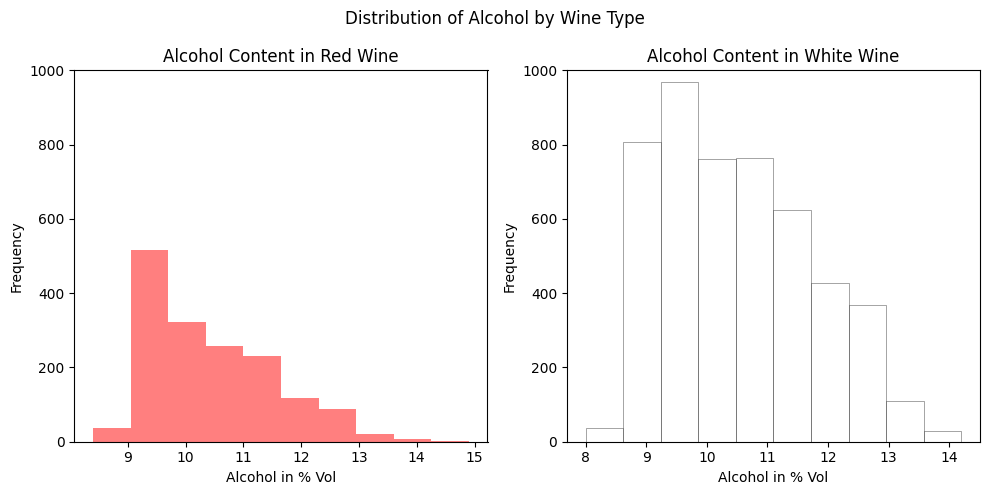

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].hist(wines[wines['type'] == 1].alcohol, bins=10, facecolor='red', alpha=0.5, label='Red wine')
ax[1].hist(wines[wines['type'] == 0].alcohol, bins=10, facecolor='white', edgecolor='black', lw=0.5, alpha=0.5, label='White wine')

for a in ax:
    a.set_ylim([0, 1000])
    a.set_xlabel('Alcohol in % Vol')
    a.set_ylabel('Frequency')

ax[0].set_title('Alcohol Content in Red Wine')
ax[1].set_title('Alcohol Content in White Wine')

fig.suptitle('Distribution of Alcohol by Wine Type')
plt.tight_layout()
plt.show()

In [6]:
X = wines.iloc[:, :-1]
y = wines['type']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.34, random_state=45)

In [7]:
model = Sequential()
model.add(Dense(12, activation='relu', input_dim=12))
model.add(Dense(9, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

c:\Users\onnok\NN-Project\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.fit(X_train, y_train, epochs=3, batch_size=1, verbose=1)

Epoch 1/3
4288/4288 ━━━━━━━━━━━━━━━━━━━━ 3s 654us/step - accuracy: 0.9079 - loss: 0.2500
Epoch 2/3
4288/4288 ━━━━━━━━━━━━━━━━━━━━ 3s 650us/step - accuracy: 0.9279 - loss: 0.2033
Epoch 3/3
4288/4288 ━━━━━━━━━━━━━━━━━━━━ 3s 658us/step - accuracy: 0.9370 - loss: 0.1792


In [9]:
y_pred = model.predict(X_test)

y_pred_labels = (y_pred >= 0.5).astype(int)

for prediction in y_pred_labels[:12]:
    wine_type = "Red wine" if prediction == 1 else "White wine"
    print(f"Prediction: {wine_type}")

70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 796us/step
Prediction: White wine
Prediction: White wine
Prediction: White wine
Prediction: White wine
Prediction: White wine
Prediction: Red wine
Prediction: Red wine
Prediction: White wine
Prediction: Red wine
Prediction: White wine
Prediction: White wine
Prediction: White wine


## prediction Fashion

In [10]:
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist

(train_data, train_labels), (test_data, test_labels) = fashion_mnist.load_data()

In [11]:
print("My train data Shape:", train_data.shape)
print("My train labels :", train_labels.shape)
print("Maximum label : ", train_labels.max())

My train data Shape: (60000, 28, 28)
My train labels : (60000,)
Maximum label :  9


Text(0.5, 1.0, 'Bag')

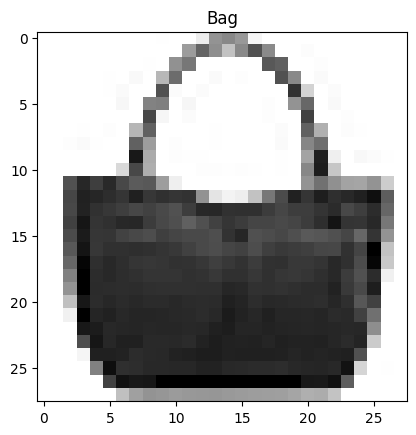

In [12]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
index_of_choice = 100
plt.imshow(train_data[index_of_choice],cmap=plt.cm.binary)
plt.title(class_names[train_labels[index_of_choice]])

In [13]:
train_data_norm = train_data / train_data.max()
test_data_norm = test_data / test_data.max()

In [14]:
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape= train_data[0].shape),
    tf.keras.layers.Dense(4, activation=tf.keras.activations.relu),
    tf.keras.layers.Dense(4, activation=tf.keras.activations.relu),
    tf.keras.layers.Dense(10, activation=tf.keras.activations.softmax)
])

model.compile(loss = tf.keras.losses.SparseCategoricalCrossentropy(),
                optimizer = tf.keras.optimizers.Adam(0.001),
                metrics = ["Accuracy"])
norm_history = model.fit(train_data_norm,train_labels,epochs=10,validation_data=(test_data_norm, test_labels))

Epoch 1/10


c:\Users\onnok\NN-Project\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 954us/step - Accuracy: 0.6258 - loss: 1.0208 - val_Accuracy: 0.7542 - val_loss: 0.7229
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 897us/step - Accuracy: 0.7706 - loss: 0.6581 - val_Accuracy: 0.7654 - val_loss: 0.6677
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 904us/step - Accuracy: 0.7871 - loss: 0.6135 - val_Accuracy: 0.7818 - val_loss: 0.6342
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 899us/step - Accuracy: 0.8002 - loss: 0.5820 - val_Accuracy: 0.7888 - val_loss: 0.6161
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 900us/step - Accuracy: 0.8062 - loss: 0.5634 - val_Accuracy: 0.7983 - val_loss: 0.5971
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 893us/step - Accuracy: 0.8107 - loss: 0.5507 - val_Accuracy: 0.8024 - val_loss: 0.5849
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 878us/step - Accuracy: 0.8129 - loss: 0.5406 - val_Accuracy: 0.8000 - val_loss: 0.5949
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 884us/step - Accuracy: 0.8156 - loss: 0.53

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 605us/step


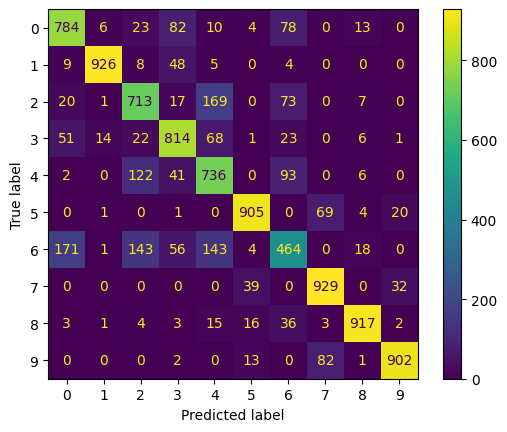

In [15]:
y_pred_probs = model.predict(test_data_norm)

# Hoogste kans kiezen
y_pred = np.argmax(y_pred_probs, axis=1)

# Confusion matrix maken
cm = confusion_matrix(test_labels, y_pred)

# Tonen
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

## Ameshousing

In [80]:
df = pd.read_excel("AmesHousing.xlsx")

In [81]:
 # Preprocessing
df["Garage"] = df["Garage"].map({"yes": 1, "no": 0})
df = pd.get_dummies(df, columns=["Neighborhood", "House Style"], drop_first=True)
 
X = df.drop(columns=["SalePrice", "ID"])
y = df["SalePrice"]
 
# Zet bool kolommen om naar int (get_dummies geeft bool terug)
X = X.astype({col: int for col in X.select_dtypes("bool").columns})
# Vul ontbrekende waarden op met de mediaan
X = X.fillna(X.median())

In [82]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [83]:

model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation="relu", input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(1)
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss="mse",
    metrics=["mae"]
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=200,
    verbose=1
)

Epoch 1/200


c:\Users\onnok\NN-Project\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 37996740608.0000 - mae: 178636.8906 - val_loss: 41553510400.0000 - val_mae: 185808.7031
Epoch 2/200
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 37971066880.0000 - mae: 178576.7031 - val_loss: 41478242304.0000 - val_mae: 185643.8438
Epoch 3/200
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 37780660224.0000 - mae: 178153.0625 - val_loss: 41042460672.0000 - val_mae: 184734.2188
Epoch 4/200
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 37024518144.0000 - mae: 176524.7500 - val_loss: 39596429312.0000 - val_mae: 181761.9844
Epoch 5/200
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 35007229952.0000 - mae: 172117.8906 - val_loss: 36162961408.0000 - val_mae: 174557.8594
Epoch 6/200
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 30942541824.0000 - mae: 162932.4375 - val_loss: 30178799616.0000 - val_mae: 161005.5469
Epoch 7/200
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 24641251328.0000 - mae: 146951.5469 - val_loss: 22004514816.0000 - val_

In [87]:
from sklearn.metrics import mean_absolute_error

pred = model.predict(X_train)

mae = mean_absolute_error(y_train, pred)

print("MAE:", mae)


65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 560us/step
MAE: 18132.150390625


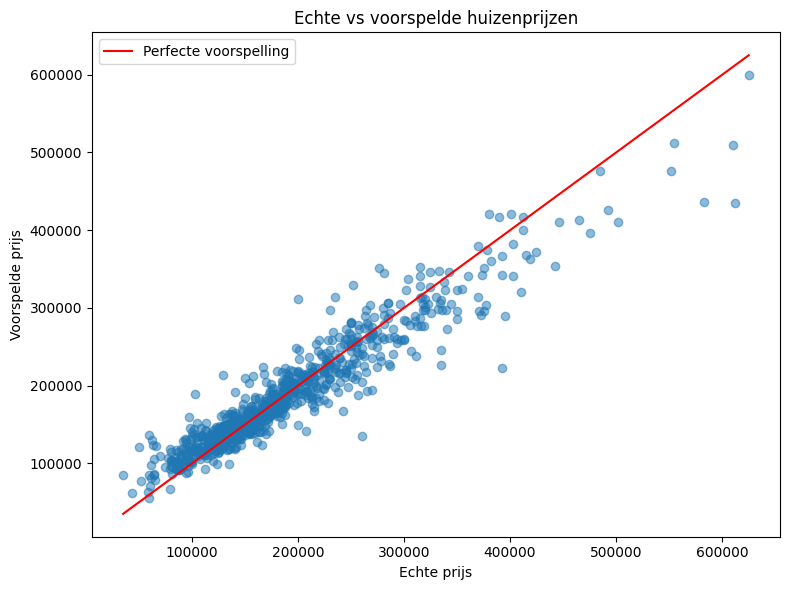

In [101]:

plt.figure(figsize=(8, 6))
plt.scatter(y_test, pred_test, alpha=0.5)
min_val = min(y_test.min(), pred_test.min())
max_val = max(y_test.max(), pred_test.max())
plt.plot([min_val, max_val], [min_val, max_val], color="red", label="Perfecte voorspelling")
plt.xlabel("Echte prijs")
plt.ylabel("Voorspelde prijs")
plt.title("Echte vs voorspelde huizenprijzen")
plt.legend()
plt.tight_layout()
plt.show()

## ames minder features

In [ ]:
df = df.loc[:, ["SalePrice", "Overall Qual",
    "Gr Liv Area",
    "Total Bsmt SF",
    "Year Built"]]

df

,SalePrice,Overall Qual,Gr Liv Area,Total Bsmt SF,Year Built
0,215000,6,1656,1080.0,1960
1,105000,5,896,882.0,1961
2,172000,6,1329,1329.0,1958
3,244000,7,2110,2110.0,1968
4,189900,5,1629,928.0,1997
...,...,...,...,...,...
2925,142500,6,1003,1003.0,1984
2926,131000,5,902,864.0,1983
2927,132000,5,970,912.0,1992
2928,170000,5,1389,1389.0,1974


In [94]:
X = df.drop(["SalePrice"], axis=1)
y = df["SalePrice"]

# Zet bool kolommen om naar int (get_dummies geeft bool terug)
X = X.astype({col: int for col in X.select_dtypes("bool").columns})
# Vul ontbrekende waarden op met de mediaan
X = X.fillna(X.median())

In [95]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [96]:

model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation="relu", input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(1)
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(0.01),
    loss="mse",
    metrics=["mae"]
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    verbose=1
)

Epoch 1/50


c:\Users\onnok\NN-Project\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


65/65 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 13103589376.0000 - mae: 84946.3438 - val_loss: 3942685952.0000 - val_mae: 41321.5703
Epoch 2/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2833923072.0000 - mae: 35632.7148 - val_loss: 2813879552.0000 - val_mae: 35341.6641
Epoch 3/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2641430528.0000 - mae: 34606.4688 - val_loss: 2354422272.0000 - val_mae: 33227.6523
Epoch 4/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2569014784.0000 - mae: 33279.5117 - val_loss: 2378411520.0000 - val_mae: 32563.8496
Epoch 5/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2504912896.0000 - mae: 32830.5195 - val_loss: 2223748864.0000 - val_mae: 32163.2168
Epoch 6/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2532740608.0000 - mae: 32791.7891 - val_loss: 2239621888.0000 - val_mae: 32019.6387
Epoch 7/50
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2779196416.0000 - mae: 34605.9648 - val_loss: 2758479360.0000 - val_mae: 34792.9961
Epoch 8/50
65/65

In [97]:
from sklearn.metrics import mean_absolute_error
pred = model.predict(X_test)

mae = mean_absolute_error(y_test, pred)
print("MAE:", mae)

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
MAE: 29292.287109375


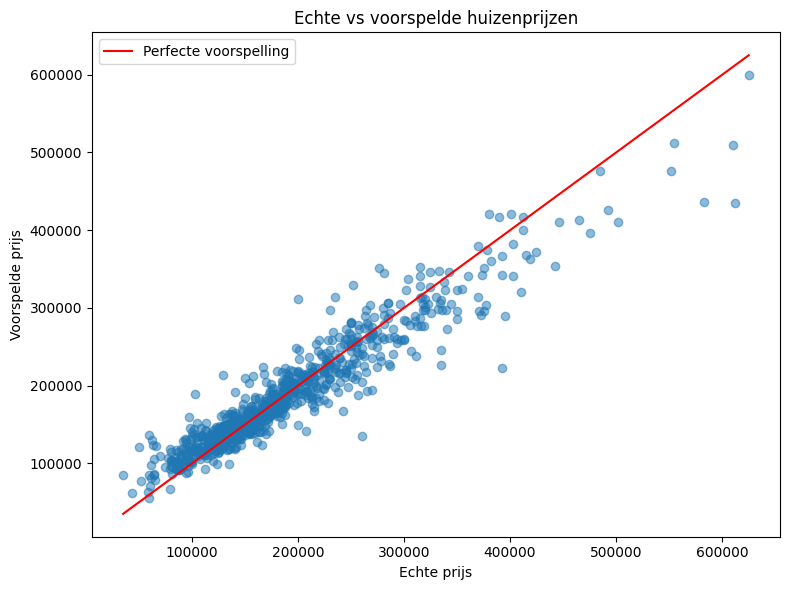

In [100]:

plt.figure(figsize=(8, 6))
plt.scatter(y_test, pred_test, alpha=0.5)
min_val = min(y_test.min(), pred_test.min())
max_val = max(y_test.max(), pred_test.max())
plt.plot([min_val, max_val], [min_val, max_val], color="red", label="Perfecte voorspelling")
plt.xlabel("Echte prijs")
plt.ylabel("Voorspelde prijs")
plt.title("Echte vs voorspelde huizenprijzen")
plt.legend()
plt.tight_layout()
plt.show()